# 1 Series, averages, waves, partition functions, DNA melting, atom entropy

In [1]:
# import all python add-ons etc that will be needed later on
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()                      # allows printing of SymPy results in typeset maths format
plt.rcParams.update({'font.size': 14})  # set font size for plots

## 1.1 Power series

The arithmetic and geometric series, the series expansions of exponential, sine, and cosine functions have been described in earlier chapters. Any regular function can be expanded in a similar manner to sine, cosine, etc. in powers of $x$, to produce its unique power series, which in general has the form

$$\displaystyle  f = a_0 +a_1x+a_2x^2 +a_3x^3 +\cdots = \sum_n a_nx^n $$
 
where the $a$'s are positive or negative constants. The capital $\sum$ is used to indicate a summation, with sub- and superscripts as necessary. In the reverse process, some series can be
summed to form a function. The power series

$$\displaystyle 1+x+x^2 +x^3 +x^4 +\cdots+x^n + $$

is a geometric series, as the ratio of consecutive terms is constant, and is summed to the algebraic expression,

$$\displaystyle \frac{1}{1-x} =1+x+x^2 +x^3 +x^4 +\cdots+x^n +\cdots   \qquad\tag {1} $$

provided that $| x | \lt 1$ where $| x |$ is the absolute values of $x$. If this condition is not true then the expansion tends to infinity and gives the wrong answer. 

The summation is easily found to a finite number of $N$ terms, let 

$$\displaystyle S_N=1+x+x^2 +x^3 +x^4 +\cdots+x^N $$

then multiply both sides by $x$ and subtract the two expressions

$$\displaystyle \begin{align}xS_N & = x+x^2 +x^3 +x^4 +\cdots+x^{N+1}\\ 
(1-x)S_n&=(1+x+x^2 +x^3 +x^4 +\cdots+x^N)-(x+x^2 +x^3 +x^4 +\cdots+x^{N+1}) \\&=(1-x^{N+1})\end{align}$$

and the summation is 

$$\displaystyle \sum_{n=0}^N x^n=\frac{1-x^{N+1}}{1-x}\qquad\tag{2a}$$

Taken to infinity the summation becomes
           
$$\displaystyle\sum_{n=0}^\infty x^n = \frac{1}{1-x }  \qquad\tag{2b} $$
 
but only if $-1\lt x\lt 1$. If the summation starts at $1$ then 

$$\displaystyle \sum_{n=1}^N x^n=\frac{x(1-x^N)}{1-x}\qquad\tag{2c}$$

### **(i) Quantised linear oscillator**

In a quantised linear oscillator the energy is given by $E=nh\nu$ where $n$ is a positive integer or zero, $h$ is Planck's constant and $\nu$ the oscillator frequency. The Boltzmann distribution gives the chance of having energy with $n$ quanta as 

$$\displaystyle p_n = e^{-nhv/(k_BT)}$$

with $k_B$ as the Boltzmann constant and $T$ temperature. Summing over all $n$ levels gives, 

$$\displaystyle \sum_0^\infty e^{-nhv/k_BT}= \sum_0^\infty \left(e^{-hv/(k_BT)}\right)^n $$

This sum is easily worked out by letting $\displaystyle x=e^{-hv/(k_BT)}$ and then from equation 2b,

$$\displaystyle \sum_0^\infty e^{-nhv/(k_BT)}= \frac{1}{1- e^{-hv/(k_BT)}} $$

The total or average energy is, by definition,

$$\displaystyle E= \frac{\sum\limits_{n=0}^\infty nh\nu\, p_n}{\sum\limits_{n=0}^\infty p_n}$$

and the sum in the numerator is given in the table below (section 2.1) and evaluated using the substitution just described. The result is 

$$\displaystyle E=\frac{h\nu}{e^{h\nu/(k_BT)}-1}$$

In the limit of high temperatures or very small values of $\nu$, where the exponential can be expanded as a series, the classical result is obtained, $E=k_BT$. Series expansion is described further in section 6.

### **(ii) Approximating a function as a series**

The function  

$$\displaystyle f(x)  = \frac{1}{1-x} $$

(eqn. 2) can be represented by the polynomial series equation (1), again this is only true if $-1\, x \, \lt 1$. The polynomial is calculated as

$$\displaystyle f(0) = 1, \quad f(1/2) = 1 + 1/2 + 1/4 + 1/8 + \cdots$$

which looks as though it will converge as terms are becoming increasingly smaller as the series grows. Convergence always needs to be checked. If $x$ is greater than 1 then the series obviously increases to infinity, which is clear to see from

$$\displaystyle f (2) = 1 + 2 + 4 + 8 + \cdots$$

The expansion of $1/(1 + x)$ and of $1/(1 + ax)$, for example, follows immediately by substitution of $x \rightarrow -x $ and $x \rightarrow ax$  into the series of equation (1). In the latter case for the series to be valid $|\, ax \,| < 1$, where $a$ is a constant.

Figure 1, below, shows the derivative of each term in $f(x)$

$$\displaystyle f^′(x)= \frac{1}{(1 - x)^2} =1+2x+3x^2 +4x^3 +\cdots+nx^{n-1} +\cdots$$

and several approximations which are ever longer series with increasing powers of $x$. Expanding the series as far as $x^6$ only matches the $f(x)$ well up to about $x = 0.5$ indicating the rather obvious fact that that many terms may be needed to accurately reproduce a function. The plot also shows how a function may be approximated by its first couple of terms when the variable $x$ is very small.  This is a very common procedure to account for a perturbation. Series expansion is described further in section 6.

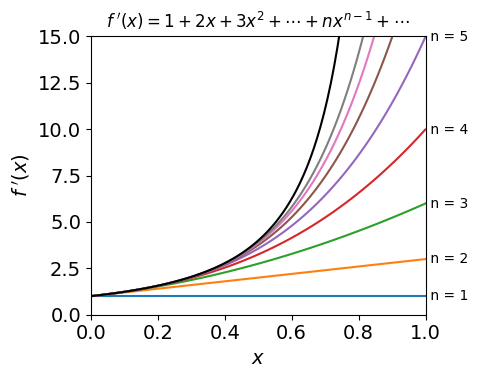

In [2]:
# A Power Series calculation

fig1 = plt.figure(figsize=(5, 4))
plt.rcParams.update({'font.size': 14})  # set font size for plots

m    = 8                             # maximum power of series is m
numx = 100                           # number of points to plot
maxy = 15                            # max y axis
s = [0.0 for i in range(numx)]       # make array of zeros
x = np.linspace(0.0,0.999,numx)

sers = lambda x,j: sum( n*x**(n-1) for n in range(1,j+1) )  # sum =1+2x+3x^2 + + nx^(n-1) ... 1/(1-x)^2
j = 1
while j <= m:
    for i in range(numx):
        s[i]= sers(x[i],j)  
    plt.plot(x,s)
    j = j + 1
    pass

plt.plot(x, 1.0/(1.0 - x)**2,color='black')            # exact expression 

txt = [ ' n = '+ str(i) for i in range(1,m+1) ]
for i, q in enumerate(txt):
    yval = sers(x[numx-1],i+1)
    if yval< maxy: 
        plt.text(1.0,yval,q,verticalalignment='center',fontsize=10)
    pass
plt.title(r"$f\;'(x)=1+2x+3x^2+\cdots+nx^{n-1}+\cdots$",fontsize=12)  # r"$...$" uses markdown
plt.xlabel(r'$x$')
plt.ylabel(r"$f\;'(x)$")
plt.axis([0.0,1.0,0.0,maxy] )
plt.tight_layout()
plt.show()

Figure 1. The function $1/(1-x)^2 $ (top black line) and its series approximations  $\displaystyle \sum_n nx^{n-1}$ with $n$ = 1, 2, $\cdots$. 
_____

## 2 Making new series

### **(i) Differentiating an existing series**

New series can often be made from existing ones. Suppose each term in the series of $f(x)=1+x+x^2+\cdots$ is differentiated, then using eqn. 2,
 
$$\displaystyle f^′(x)= \frac{1}{(1 - x)^2} =1+2x+3x^2 +4x^3 +\cdots+nx^{n-1} +\cdots  \qquad\tag{3}$$
         
and if $| \,x\, | \lt 1$ this is the expansion of $ 1/(1 - x)^2$, which can be written as

$$\displaystyle \sum_{n=0}^{\infty}   nx^{n-1} = \frac{1}{(1 - x)^2}  \qquad\tag{4}$$

### **(ii) Substituting $x \to -x $**
 
Substituting $x \to -x $ gives the series

$$\displaystyle \frac{1}{(1 + x)^2} =1-2x+3x^2-4x^3 +\cdots      \qquad\tag{5}$$

The summation expression is 

$$\displaystyle \sum_{n=1}^\infty (-1)^n nx^{n-1} = \frac{1}{(1+x)^2}$$

and the $\displaystyle (-1)^n$ ensures that alternate terms are positive and negative.

### **(iii)  Summation** 

$$\displaystyle \sum_{n=0}^\infty (1-x)x^n = 1,\qquad |x|\lt 1$$

and the new sum $\displaystyle \sum_{n=0}^\infty x(1-x)^n$ can be found with this result by substituting $y=1-x$ then 

$$\displaystyle \sum_{n=0}^\infty y(1-y)^n = 1,\qquad |y-1|\lt 1$$

but notice that there are now new limits.

## 2.1 Table of Summations

$$\displaystyle \small \begin{array}{lll}
\hline
\sum_0^\infty\limits x^n = \displaystyle\frac{1}{1-x}, & |x|<1&
\sum_0^\infty\limits (-x)^n = \displaystyle\frac{1}{1+x},&  |x|<1&\\
\sum_0^\infty\limits nx(1-x)^n=\displaystyle \frac{1-x}{x},& |x-1|<1&
\sum_0^\infty\limits (1-x)x^n =1,& |x|<1\\
\sum_0^\infty\limits nx(1-x)^{n-1} =\displaystyle\frac{1}{x},& |x-1|<1&
\sum_0^\infty\limits x(1-x)^{n-1} =\displaystyle\frac{1}{1-x},& |x-1|<1\\
\sum_0^\infty\limits n(1-x)x^{n-1} =\displaystyle\frac{1}{1-x},& |x|<1&
\sum_0^\infty\limits nx^n =\displaystyle\frac{x}{(1-x)^2},& |x|<1\\
\sum_0^\infty\limits n(1-x)x^n =\displaystyle\frac{x}{1-x},& |x|<1\\
\hline
\end{array}$$

## 2.2 Convergence. Ratio test

In summing a series, it is important to ensure that it converges to some sensible expression such as $1/(1 - x)$, and is not going to be infinite or undefined. With many series, the summation is infinite and cannot therefore be expressed in a simple form. There are a number of convergence tests to ensure that a series has a finite result; many of these are complex, but a ratio test is a good way of determining if the series will be finite.
In the ratio test, the ratio of any term $w$ in the series to its preceding term is calculated

$$\displaystyle r=\lim_{n=+\infty} \left| \frac{w_{n+1}}{w^n} \right| $$

and then the limit is taken as $n$ tends to infinity. If the $(n + 1)^\text{th}$ term is smaller than the $n^\text{th}$, then the series is converging. The second step is to check whether $r \lt 1$, as $n$ goes to infinity.

In the series expansion of $\displaystyle (1 - x)^{-1} = 1 + x + x^2 \cdots$ any individual term in the series is $x^n$ so the ratio $\displaystyle r = \lim_{n \rightarrow \infty} \left| \frac{x^{n+1}}{x^n} \right | = |x|$ is less than 1 only if $|x| \lt 1$; therefore when this is true the series converges. The interval of convergence for this sum is 0 $\le x \lt 1$, and the radius of convergence $s = 1$. For any other values this series diverges. 

Should the radius $s$ be infinity the series is convergent for all values of $x$; for instance, the exponential series is convergent for all $x$. Testing for convergence properly is far more complicated than this example leads us to believe and a maths textbook should be consulted to understand how to do this rigorously.

In general, a series converges if $x$ is smaller than some number $s$, so that $|x_0 - x| \lt s$ where $x_0$ is a displacement about which the series converges; see Section 6 describing Taylor series for examples of this. The number $s$ can be determined from the convergence test, Fig. 1. A useful property is that if a power series converges to some number and if each term of it is differentiated, the resulting series can be shown also to converge.

## 3.1 Summation of waves
The summation of waves occurs in fourier analysis, a wave in its general form is $e^{-i\omega t}$ which propagates at frequency $\omega$ and time $t$. The sum of many waves of different frequency and in phase with one another produces a pulse, this is how a pulse is formed in a mode-locked laser. It is also how diffraction from an array of scatterers, (electrons in atoms) produces a spot in a x-ray diffraction pattern from a single crystal. The sum to $N$ terms is formed from waves at frequencies $n\omega$, 

$$\displaystyle S=\sum_{n=-N}^N e^{-in\omega t}$$

where $i=\sqrt{-1}$. The limits here are $-N\to N$ and this changes the summation to $\displaystyle \frac{-x^{N+1}+x^N}{1-x}$ as may be worked out following the method above. Substituting $x\to e^{-i\omega t}$ gives

$$\displaystyle S=\frac{-e^{i(N+1)\omega t}+e^{-iN\omega t}}{1-e^{i\omega t}}$$

this can be further simplified by multiplying top and bottom of the fraction by $e^{-i\omega t/2}$, which is in effect multiplying by one.

$$\displaystyle S = \frac{e^{-i\omega(N+1/2) t} - e^{i\omega (N+1/2)t}}{e^{-i\omega t/2}-e^{+i\omega t/2}}$$

and using the definition of a sine in terms of exponentials $\sin(x)=(e^{ix}-e^{-ix})/2i$ gives

$$\displaystyle S=\frac{\sin\big((N+1/2)\omega t\big)}{\sin(\omega t/2)}\qquad \tag{2d}$$

which is a series of spikes separated by $2\pi/\omega$, see fig. 21b chapter 9 (Fourier transforms). 

### **(i) The Mode-Locked laser**

A mode-locked laser produces a continuous train of short light pulses and these can be very short indeed, just a few femtoseconds, for example $20\cdot10^{-15}$ seconds, is quite easily obtained from a Ti-sapphire laser. In these lasers the gain material consists of Ti ions doped into $\mathrm{Al_2O_3}$ (sapphire) crystals. The short pulses are possible because the Ti ions are in a wide variety of environments so that their emission spectrum is wide. The connection between pulse width and energy(frequency) spread is $\Delta t \sim k/\Delta \nu$ where $k$ is a constant of order of unity. (The value of $k$ depends on the shape of the laser pulse, 0.44 for a gaussian shaped (transform limited) pulse). Thus a gas-laser with a narrow atomic emission line can only produce pulse of $\sim 0.1$ ns but a Ti sapphire laser with a fwhm of $\sim 700 \to 900$ nanometres which is a frequency spread of $\Delta \nu \approx 3175\,\mathrm{cm^{-1}}$ can potentially produce a pulse of $\Delta t = 10$ fs duration. 

Suppose that the laser is running in a continuous way (continuous wave or cw), in this case the phases of the waves are random. This means that the standing waves at each of many wavelengths that exist in the cavity are oscillating independently of one another. To make a pulse these modes have all to be made to oscillate together, i.e. in phase with one another, thus these numerous modes must be locked together. Mode-locking can be produced in a variety of ways but this always involves modifying the 'gain' in the laser cavity, where 'gain' means the amplification of the light.

If the the laser cavity is perturbed in some way it is possible for the most intense part of the circulating light to produce more gain at the expense of the less intense parts. These more intense modes will then become more intense and so on, and eventually more of them become locked together simply because these are the only ones left with any amplitude. The result is that a pulse moves end to end in the cavity with a small amount of this being lost through the output coupler mirror each round trip which produces a train of pulses. Each pulse is separated by the round trip time $2L/c$ seconds from its neighbour, where $L$ is the optical path-length in the laser and $c$ the speed of light, thus for a $1.5$ m cavity pulses are produced $10$ ns apart. The perturbation to start mode-locking can be in the form on an acoustic modulator inside the cavity, a saturable absorber or in the case of Ti-sapphire lasers by tapping one mirror. This minor motion causes the gain to oscillate and so a pulse is formed as the most intense part of this stimulates more photons and so on to form a pulse. 

The total electric field of the radiation inside the cavity has very many modes, these are called *longitudinal* modes (Svelto, 1982). Such a mode is a wave that that has an integer number $n$ of half wavelengths and so fits exactly into the cavity. Not all wavelengths will do this and so do not exist in the laser output. At a wavelength $\lambda_n$ the condition is $n\lambda_n/2 = L$. However, at a slightly different wavelength $(n+1)\lambda_{n+1}=2L$ is also true. The typical length for a mode-locked laser is $1.5$ m and if the wavelength is $800$ nm then $n=3750000$ making the next mode at a wavelength of $3/3750001= 799.99978$ nm thus these modes are extremely close in wavelength, and consequently there are a vast number of modes making up the laser pulse. Instead of calculating the change in wavelength frequency can be used making the  separation of the modes $\Delta \nu=c/2L$ Hz or $\tau=2L/c$ seconds. The pulse moving round the cavity means that the phase of these modes is locked together and it is this effect that makes the pulse; random phases of sine waves would cancel one another out, see fig 18 in section 5.7 of this chapter.

To calculate the laser output we suppose that all the longitudinal modes are of equal intensity $E_0$ and the phase difference between two consecutive modes is fixed and equal to $\varphi$, the total electric field of the radiation is the sum of all the longitudinal modes which is,

$$\displaystyle E(t)=E_0\sum_{j=-n}^n \exp\big(i(\omega_0+j\Delta \omega)t+j\varphi\big)$$

where $\omega_0$ is the frequency of the central mode, which we give a phase of zero, and $\Delta \omega$ the frequency difference between two adjacent modes and is $\Delta\omega =\pi c/L$. Note that $\omega=2\pi \nu$. This summation is closely related to that leading to eqn. 2d and is

$$\displaystyle \begin{align}E(t)& =A(t)e^{i\omega_0 t}\\A(t)&=E_0
\frac{\sin\big((2N+1)(\Delta\omega t+\varphi)/2\big)}{\sin\big(( \Delta\omega t+\varphi)/2\big)}\end{align}$$

The intensity measured on a photodiode or other 'square law' detector is $E(t)E^*(t)=A(t)^2$ where $E^*$ is the complex conjugate. Some pulses are shown in the figure. The sine terms ensure that the pulse repeats itself at intervals of $\tau=2L/c$. The pulse width is 

$$\displaystyle \Delta \tau \approx \frac{2\pi}{(2n+1)\Delta \omega}$$

which shows that a large number of oscillating modes, and hence a broad emission spectrum, are needed to produce a short pulse. 

![Drawing](series-fig00a.png)

fig 1a. Mode-locked laser pulses, calculated as the square of the amplitude of the electric field, only ten modes were used in the calculation each with equal amplitude and it is clear that pulses are produced even with this small number of modes.
__________________________

## 3.2 Diffraction
Suppose that there is a line of identical oscillators each emitting waves in the arrangement of figure 1b. These could be a row of slits in a transmission grating or reflective strips in a reflection grating but in either case the sources are all in phase and emit over all angles. Thy could also be water waves or scattered off atoms by x-rays. If we observe at some distant point, a distance many times larger than the grating period $d$, and at an angle $theta$ we would like to know how the intensity of the summed waves varies as $\theta$ is changed. At some angles the waves will be in phase with one another and so produce a wave of maximum amplitude, less so at another angle and at yet other angles be completely out of phase. Thus we expect to repeatedly see bright and dark regions as the angle is changed. 

The calculation to do this means adding up the path lengths from each emitter and seeing what the total path is. The total number of wavelengths does not matter just what the surplus over a whole number of waves is, as this determines the phase and hence amplitude.

Using figure 1b, the difference in path-length between $r_1$ and $r_0$ is $r_1-r_0=\delta$ and at the angle drawn $2\delta=\lambda $. The distance between $r_2-r_1=2\delta$ and so on thus $n\delta=r_n-r_0$. 

![Drawing](series-fig0.png)

Figure 1b. An array of $N$ coherent oscillators separated by spacing $d$. The path difference measured from the first oscillator is $n\delta$ where $n=0,1\cdots N-1$. At the angle shown $2\delta =\lambda$ where $\lambda$ is the wavelength.
______

The general form is a wave is $e^{i(kr-\omega t)}$ where $\omega$ is the frequency and $k=2\pi/\lambda$ is the wavevector. If all the emitters have the same amplitude then the total wave is 

$$\displaystyle E=E_0\left(e^{i(kr_0-\omega t)}+e^{i(kr_1-\omega t)}+\cdots +e^{i(kr_{N-1}-\omega t)}\right)$$

which is simplified by factoring out $e^{-i\omega t}$ to give

$$\displaystyle E=E_0e^{-i\omega t}\left(e^{ikr_0}+e^{ikr_1}+\cdots +e^{ikr_{N-1}}\right)$$

The term in brackets can be further simplified by factoring out the first term in $r_0$ and using the definition of $\delta$ worked out from figure 0. This produces

$$\displaystyle E=E_0e^{-i\omega t}e^{ikr_0}\left(1+e^{ik\delta}+e^{2ik\delta} +\cdots +e^{(N-1)ik\delta}\right)$$

If we substitute $x=e^{ik\delta}$, this series becomes $\displaystyle \sum_{n=0}^{N-1} x^n=\frac{1-x^N}{1-x}$ and by substituting back gives

$$\displaystyle E=E_0e^{-i\omega t}e^{ikr_0}\frac{e^{ik\delta N}-1}{e^{ik\delta}-1}$$

The intensity measure on a detector, such as a CCD, is $I=E^*E$ giving

$$\displaystyle I=I_0\left(\frac{e^{-ik\delta N}-1}{e^{-ik\delta}-1}\right)\left(\frac{e^{ik\delta N}-1}{e^{ik\delta}-1} \right) =I_0\frac{2-e^{-ik\delta N}-e^{ik\delta N}}{2-e^{-ik\delta}-e^{ik\delta }}$$

Converting the exponential to cosines using $2\cos(x)=e^{-x}+e^{-ix}$ gives

$$\displaystyle I=I_0\frac{1-\cos(k\delta N)}{1-\cos(k\delta)}$$

The maximum intensity can be found when $\delta =0$ because all the oscillators with be in phase at $\theta=0$. Differentiating w.r.t. $\delta$, putting $\delta =0$ and using l'Hopital's rule, where the top and bottom is differentiated separately until the ratio is not $0/0$, gives

$$\displaystyle I(max)\to \frac{N\sin(k\delta N)}{\sin(k\delta)} \to N^2\frac{\cos(k\delta N)}{\cos(k\delta)}\to N^2$$

and the maximum intensity is $I_{max}=N^2I_0$ as intuition would dictate for $N$ identical oscillators. However, by the nature of cosines we expect the waves to come into phase each time the cosine has a value of $1$ and this will happen when $k\delta =2\pi m$ where $m=0,\pm 1,\pm 2\cdots$ where $m$ is a positive integer.

The path length difference is related to the angle $\theta$ as

$$\displaystyle \delta = d\sin(\theta)$$

then the intensity becomes

$$\displaystyle I=I_0\frac{1-\cos\big(Nkd\sin(\theta)\big)}{1-\cos\big(kd\sin(\theta)\big)}$$

and has maxima at $\theta=0,\pm \pi, \pm 2\pi\cdots$. 

This last equation is more often put into a sine form using the identity $1-\cos(x)=2\sin^2(x/2)$ which produces

$$\displaystyle I=I_0\frac{\sin^2\big(Nkd\sin(\theta)/2\big)}{\sin^2\big(kd\sin(\theta)/2\big)}\qquad \tag{2e}$$

which is the square of a *sinc$ function, i.e. a central lobe plus decreasing oscillations to either side.

## 3.3  Average concentration from the time course of drug action

When an antibiotic is administered the course normally lasts for several days, typically with tablets taken $2$ or $3$ times daily. The medication has to enter the blood stream to be dispersed to other organs, then acts on its target site and from here or from the blood it is excreted. Ideally, when taken the drug's concentration rises rapidly compared to its removal and thus gradually decreases in concentration as time proceeds. It rises rapidly again with each dose taken. The concentration vs time therefore has a saw-tooth profile whose *average* value rises initially then reaches a steady value. An oscillating steady value may be reached when the amount decayed  balances the amount added in the dose. If the time between doses is to large, the steady-state can never be reached in a sensible amount of time. Conversely, if the time between doses is too short the accumulated amount may become far too large to be a safe dose. An alternative way of calculating the time profile is given in Chapter 9-7.3 (Fourier Transforms). 

Typically a two compartment model is used to describe the kinetics involved. This can be represented as 

$$\displaystyle \large \begin {align}\overset{k_0}\longrightarrow & A\overset{k_{12},k_{21}}\rightleftharpoons B \\ & \downarrow k_3\end{align}$$

where $A$ represents blood and $B$ the target site for the drug. Clearly this is a complicated kinetic scheme and which can be solved by matrix methods described in chapter 10. When multiple doses are given the algebra becomes extremely complicated, however, if we concentrate just on the points at which the medication is administered the maximum, minimum and average dosage can be found using some of the series just described. To make the equations simpler we shall ignore species B, and suppose that species A is instantaneously populated, such as by intra-venous injection, and further that A decays by first order kinetics. These are all rather drastic simplifications but will serve, nevertheless, to illustrate the nature of what actually happens. The time profile is shown in figure 1c. 

![Drawing](series-fig0a.png)

Fig. 1c. The concentration profile of a drug as more doses are taken at intervals $\tau$. It is assumed that the uptake of the drug is effectively instantaneous (say by intra-venous injection) and is removed from the body by a first - order process. (i.e. by exponential decay). The points $a_1\cdots$ and $b_1\cdots$  are used to calculate the steady state maximum/minimum and average concentration. The lower curve shows the decay from the first dose. It is present over the whole time range as is that from every other dose. These are not shown for clarity. The dots show the average concentration at the point of each new dose,  the short horizontal lines the maximum and minimum amounts as calculated below $c_{a_N},c_{b_N}$. In plotting this figure $\tau =1$ and $k=1/2$.
________________________________

The time between taking the drug is constant at $\tau$ and we let it decay away with rate constant $k$. The decay is shown in fig 1c as the lower grey line. The same decay occurs, of course, from every dose and so adds into the total as time proceeds. Calculating the whole time profile is rather complicated and needs the use of the Heaviside function (a step function) introduced at each dosage point. (The Heaviside function prevents the exponential terms becoming $e^{+k(t-t_a)}$ when $t_a \gt t$ rather than decaying as $e^{-k(t-t_a)}$).

If each dose is $c_0$ then first dose decays as $c=c_0e^{-kt}$, and at time $\tau$ (point $a_1$ in the figure) the amount present is 

$$\displaystyle \frac{c_{a_1}}{c_0}=e^{-k\tau}$$

and at point $b_1$ as an amount $c_0$ has been added giving

$$\displaystyle \frac{c_{b_1}}{c_0} = 1+ e^{-k\tau}$$

and at points $a_2$ at time $2\tau$, another $e^{-k\tau}$ of that present is used up. An amount $c_0$ is again added to give point $b_2$ where,

$$\displaystyle \frac{c_{a_2}}{c_0} = (1+ e^{-k\tau})e^{-k\tau},\qquad \frac{c_{b_2}}{c_0} =1+ (1+ e^{-k\tau})e^{-k\tau}$$

We can continue this process and it becomes clear that the upper points ($b_1\cdots$ ) have the form 

$$\displaystyle \frac{c_{b_N}}{c_0}=1+e^{-k\tau}+e^{-2k\tau}+e^{-3k\tau}+\cdots= \sum_{n=0}^N e^{-nk\tau}$$

and the lower points ($a_n$) have the form

$$\displaystyle \frac{c_{a_N}}{c_0}=e^{-k\tau}+e^{-2k\tau}+e^{-3k\tau}+\cdots= \sum_{n=1}^N e^{-nk\tau}$$

where the summation starts at $n=1$. Using equations (2) the amounts after $N$ doses at time points $N\tau$ are

$$\displaystyle \frac{c_{a_N}}{c_0}=\frac{e^{-k\tau}(1-e^{-k\tau N})}{1-e^{-k\tau}},\qquad \frac{c_{b_N}}{c_0}=\frac{1-e^{-k\tau (N+1)}}{1-e^{-k\tau}}\qquad\tag{2f}$$

from which the average dose can be calculated as

$$\displaystyle \frac{c_{av}}{c_0}= \frac{1+e^{-k\tau}-2e^{-k\tau(N+1)}}{2(1-e^{-k\tau})} \qquad\tag{2g}$$ 

and as $k\tau$ is a constant the steady state is found when $e^{-k\tau (N+1)} \ll e^{-k\tau}$ which happens when $N$ is large enough so that $e^{-k\tau N} \ll 1$. In the figure above $k\tau =1/2$ so that when $N=6$, $e^{-k\tau N} \approx 0.05$ and as can be seen in the figure, when this is the case steady-state is almost reached.

## 4 Average quantities

Any quantity, $x$, which is one of a set of measurements has an average value

$$\displaystyle \langle x \rangle= \frac{\sum xp(x)}{\sum p(x)}      \qquad\tag{6}$$

and this is also called the _first moment_ of the distribution $p(x)$; the second moment is $\langle x^2 \rangle$, the fourth $\langle x^4 \rangle$, etc. The average of $x^2$ is

$$\displaystyle  \langle x^2 \rangle = \frac{\sum x^2p(x)}{\sum p(x)} \qquad\tag{7}$$

The variance or standard deviation squared of $x$ is

$$\displaystyle \sigma^2 =\langle x^2 \rangle -\langle x \rangle^2 $$

A more meaningful description is that $\sigma$ is the _dispersion_ in the value of $x$, meaning it is the spread in its value; experimental values are often quoted as $\langle x \rangle \pm \sigma$. The chapter on integration has examples of averaging using integrals rather than summations, and variance is described in Chapter 13 Data analysis.

## 4.1 Average energy of a molecule or atom 

The average energy is described by

$$\displaystyle \langle E \rangle = \frac{\sum Ep(E)}{\sum p(E)} \qquad\tag{8}$$

where the summation covers all the energy states and $p(E)$ is the distribution function, which is very often a thermal or Boltzmann distribution, $\displaystyle p(E) = e^{-E/k_BT}$ with temperature $T$ and Boltzmann’s constant $k_B$. In special situations this might be replaced by the Bose-Einstein or Fermi-Dirac distribution among others. 

If the lowest energy is zero and the largest infinity and $E$ has discrete integer values, in units of $k_BT$, the average energy is, by definition,

$$\displaystyle \langle E \rangle=\frac{\sum_{E=0}^\infty\limits Ee^{-E/k_BT}}{\sum_{E=0}^\infty\limits e^{-E/k_BT}}\qquad\tag{8a}$$

The denominator is called the partition function (see Section 4) and using the property of exponentials $\displaystyle  e^{nx} = (e^x)^n$ is written as

$$\displaystyle Z=\sum_{E=0}^\infty {\left(e^{-1/k_BT}\right)^E} =\frac{1}{1 - e^{-1/k_BT}}\qquad\tag{8b}$$

based on the summation $\displaystyle \sum_{n=0}^\infty x^n = (1-x)^{-1}$ and by substituting $\displaystyle x = e^{-1/k_BT}$. 

Some guile is now needed in writing the numerator, which becomes $\displaystyle e^{-1/k_BT} \sum_{E=0}^\infty E(e^{-1/k_BT})^{E-1}$. Notice that $\displaystyle e^{-1/k_BT}$ is placed outside the summation to get the summation into the mathematical form $\displaystyle \sum_{E=0}^\infty Ex^{E-1}= (1-x)^{-2}$, see eqn. (4), which when $x$ is substituted gives,

$$\displaystyle  \sum_{E=0}^\infty Ee^{-E/k_BT}= \frac{e^{-1/k_BT}}{(1-e^{-1/k_BT})^2}\qquad\tag{8c}$$

Dividing by the partition function $Z$ produces the average energy

$$\displaystyle  \langle E \rangle = \frac{e^{-1/k_BT}}{1-e^{-1/k_BT}} = \frac{1}{e^{1/{k_BT}}-1}$$

This result is interesting and evaluating by expanding the exponential assuming  $k_BT \gg 1$ produces $k_BT$ which is $\approx 208\;\mathrm{cm^{-1}}$ at $300$ K. This means that every molecule has the same total average energy when $k_BT \gg 1$. However, this is not the case if just individual energy levels are considered, such as vibrations or rotations. Rewriting the partition function to sum over an index rather than $E$ which means that $E_i$ has individual values depending on the particular type of energy level in the molecule or atom, making equation 8b,

$$\displaystyle Z = \sum _i e^{-E_i/k_BT}$$

and if differentiated with respect to $T$,

$$\displaystyle \frac{dZ}{dT}=\frac{d}{dT}\sum_i e^{-E_i/k_BT}=\frac{1}{k_BT^2} \sum_i E_ie^{-E_i/k_BT} $$

which is related to the average energy from equation 8c; $\langle E\rangle = \sum_{i} E_ie^{-E_/k_BT}/Z$ and therefore by substituting with the derivative and rearranging the average energy is

$$ \displaystyle \langle E\rangle =k_BT^2\frac{1}{Z}\frac{dZ}{dT}=k_BT^2\frac{d\log(Z)}{dT}\qquad\tag{8d}$$

If rotational levels are considered typically several tens of levels are populated at room temperature and the summation therefore involves many terms, for example if the rotational constant $B=1\;\mathrm{cm^{-1}}$, $\approx 55 $ levels are needed to produce a constant average energy of $\approx 14500\;\mathrm{cm^{-1}}$. A vibration of $1000\;\mathrm{cm^{-1}}$ levels only to $n=2$ are needed to produce four figure accuracy of $500.4 \; \mathrm{ cm^{-1}}$.

## 4.2 Polymers
In synthesizing polymers by radical or condensation polymerisation, the random nature of the chemistry that adds monomers to an already growing chain dictates that a range of polymer lengths is normally produced; the polymer is poly-disperse. Two different averages are frequently taken to characterize the polymer; one is the number average mass, the other the weight average mass. The reason for having two averages is two fold. Since there in not single polymer length (or mass) but a distribution of these measures of the shape/width of this distribution is needed to characterise the polymer. Secondly the number average is measured by colligative properties such as osmosis, whereas size/mass is measured by light scattering.

The number average mass $m_n$ is

$$\displaystyle \langle m_n \rangle = \frac{\sum_k m_kp(n_k)}{\sum_k p(n_k)} = \frac{n_1m_1+n_2m_2 +\cdots }{n_1+n_2+\cdots} \qquad\tag{9}$$

where $p$ is the distribution of the number of polymers of length $k$ and $m_k$ is the mass of each polymer $k$. The sum  $\sum p(n_k) = N$  the total number of molecules. This average can also be written in terms of the weight as

$$\displaystyle \langle m_n \rangle =  \frac{\sum_k w_k}{\sum_k (w_k/m_k)} $$

The weight (mass)average mass is

$$\displaystyle \langle m_w \rangle = \frac{\sum_k \limits m_k\cdot m_kp(n_k)}{\sum_k\limits m_kp(n_k)} = \frac{n_1m_1^2+n_2m_2^2 +\cdots }{n_1m_1+n_2m_2+\cdots} \qquad\tag{10}$$

Statistically $\langle m_n\rangle$ is the first moment of the distribution $p$, but $\langle m_w\rangle$ is the  ratio of the first and second moments.   If the number average and mass (weight) average is the same, the polymer is mono-disperse, however, this is not usually the case. To illustrate that these two averages are different, suppose the number distribution, which may not necessarily relate to a particular polymer but has approximately the right shape, is $\displaystyle p(n_k) = n_ke^{-an_k}$ where $a$ is a positive constant roughly describing the width of the distribution. If $n_k = k$ then, by definition, the number of moles of polymers with length $1$ is $1$ and the number of length $2$ is $2$ and so forth. The mass of the polymer with $k$ segments is $m_k = km_0$, if $m_0$ is the mass of a mole of monomer units, then the number average, if $k$ is taken to infinity, is

$$\displaystyle \langle m_n\rangle = m_0 \frac{\sum_{k=1}\limits k^2e^{-ak}}{\sum_{k=1}\limits ke^{-ak}} = m_0\frac{e^a+1}{e^a-1}$$

In contrast the weight average is

$$\displaystyle \langle m_w\rangle = m_0 \frac{\sum_{k=1}\limits k^3e^{-ak}}{\sum_{k=1}\limits k^2e^{-ak}} = m_0\frac{4e^a+e^{2a}+1}{e^{2a}-1}$$

which is clearly not the same as $\langle m_n \rangle$. The two averages are approximately linear, for $a<1$, if plotted on a log-log plot and have a negative slope, with $\langle m_w\rangle \gt \langle m_n\rangle$. When $a \gt 1$ the two curves converge to a limiting value of $m_0$.

## 4.3 Sequence repeats in DNA

Our DNA is packaged into $46$ chromosomes (22 pairs and 2 sex chromosomes) but each chromosome is still too vast to analyse and so it is broken into more manageable pieces by mechanical or chemical or enzymatic means. If we want to identify a particular sequence, say of $n$ base pairs  we will want to estimate what is the average separation of these is so that a suitable number of fragments are present containing the sequence.  It is assumed that the DNA is initially so long, $\sim 10^6$ base pairs, that overall there are equal amounts of GCAT bases. If the sequence to identify is $n=8$ bases long and is GGCATGGA then the chance of finding the first G is $1/4$ and of the second adjacent G is $ 1/16$ and as each event is independent of any other the probabilities multiply to give 

$$\displaystyle p=\frac{1}{4}\frac{1}{4}\frac{1}{4}\cdots= \frac{1}{4^n}$$

thus for $n=8$ the chance of finding any specified consecutive sequence is very small $1/4^8=1/65536$. This is true whatever the sequence is as long as the bases are in a fixed order. To detect an 8-mer the fragment will, of course, have to have on average at least these many bases since we do not know before hand if the sequence is present. What then is the average distance from one sequence to the next? The probability of _not_ seeing the next sequence in $m$ moves is $(1-1/4^n)^{m-1} $ and then seeing one in the next move is the product

$$\displaystyle p(m)=\left(1-\frac{1}{4^n}\right)^{m-1}\frac{1}{4^n}$$

With the substitution $p=1/4^n$ the average is therefore

$$ \mu= \frac{\sum_{m=0}^\infty\limits m\left(1-p\right)^{m-1}p}{\sum_{m=0}^\infty\limits \left(1-p\right)^{m-1}p}$$

The normalisation (denominator) is the sum 

$$\displaystyle \frac{1}{1-p}\sum_{m=0}^\infty\limits \left(1-p\right)^{m}p=  \frac{1}{1-p}\to 1$$

because $p\lt\lt 1$. The numerator is 

$$\displaystyle \frac{1}{1-p}\sum_{m=0}^\infty\limits mp\left(1-p\right)^m= \frac{1}{p}$$

so the average is

$$\displaystyle \mu = \frac{1}{p}=4^n$$

which means that when the sequence is long a huge number of base pairs are needed, on average, if the sequence is to be present more than once. This is important in PCR where a sequence of perhaps $15 \to 30 $ primer base pairs are used to identify and so amplify the DNA. This primer sequence is sufficiently long that the probability of this occurring by random is tiny in fragmented DNA with only a few thousand base pairs. This makes the PCR amplification very specific indeed, i.e. if the target sequence is not there, amplification is highly unlikely to occur by random chance.    



## 5 Partition Functions

One of the commonest uses of the summation of a series of terms is in the calculation of the partition function. These are met formally in statistical mechanics but are also used in kinetic theory and in spectroscopy.

The partition function is the *sum over states* of the distribution of energy levels usually assumed to follow Boltzmann's exponential law (or distribution), which describes the probability

$$\displaystyle pdE = ge^{-E/k_BT}dE$$

that an atom or molecule has energy in the range $E$ to $E + dE$ and where $g$ is the degeneracy of the energy level, $k_B$ is the Boltzmann constant  ($1.3805 \cdot 10^{-23}\,\mathrm{ J K^{-1} }$) and $T$ the temperature. This distribution is obtained by considering the most probable way of arranging a fixed number of particles among all the available energy levels in a constant volume and with a constant total energy. Related distributions, but applicable only in certain circumstances, are the Fermi-Dirac and Bose-Einstein.

The German word for the partition function, *Zustandssumme*,  translates as 'sum over states'. In English, it is called the partition function because it describes how much energy is in one level compared to the total, i.e. how energy is partitioned when the system, an ensemble of molecules for example, is in contact with a heat bath. A distribution based on being in thermal equilibrium with a heat bath is called a *canonical* distribution. Once the partition function is calculated all the various thermodynamic properties, such as heat capacity, entropy and free energy, can be calculated. 

The partition function is the summation over all the energy levels

$$\displaystyle Z = \sum_{i=0}^m g_ie^{-E_i/k_BT}  \qquad\tag{11}$$

which extends over all energy levels from $i = 0 \cdots m$. The energy of the $i^th$ level is $E_i$, its degeneracy $g_i$. A state is degenerate if it has more than one energy level, the number of these levels is called the *multiplicity*. The vibrational levels in molecules are singly or non-degenerate, the rotational levels are degenerate and have a multiplicity that increases with the quantum number and is $g_J = 2J + 1$ where $J$ is the quantum number. In some situations, such as the harmonic oscillator, there is an infinite number of levels to sum in the partition function and $m = \infty$; in others, such as when an atom is in a magnetic field, there is a finite number.

The fractional population in any one level is the ratio 

$$\displaystyle  f_i = \frac{n_i}{N}=\frac{g_ie^{-E_i/k_BT}}{\sum_{i=0}^m\limits g_ie^{E_i/k_BT}}  \qquad\tag{12}$$

and the partition function normalizes the expression. $N$ is the total number of particles. The partition function assumes that the energy is based on a thermal scale starting at zero, if this is not the case plausible answers can be obtained, which on scrutiny may prove to be wrong. The way to avoid this is always to make the energy scale start at zero; Q10 illustrates this effect.

We can derive the fraction in another way. As the total probability that a 'particle' has to be in one of possibly many states must be one, $\sum_i p_i = 1$ where $p_i$ is the probability of being in state $i$ and is proportional to the statistical weight from that state and hence 

$$p=\alpha g_i e^{-E_i/k_BT}$$

where $\alpha$ is the normalisation constant. The total probability is therefore 

$$\sum_i p_i=\alpha \sum_i g_ie^{-E_i/k_BT}=1$$

and therefore 

$$\alpha = \frac{1}{\sum_i g_ie^{-E_i/k_BT} }$$

Conventionally we write $\alpha=1/Z$ and the probability that the particle is in level $i$ becomes

$$\displaystyle p_i = \frac{g_ie^{-E_i/k_BT}}{Z}$$

which is equation 12. The partition function, $Z$, is the normalization term and determines what fraction of the total energy is in each level or how energy is partitioned among the various level

## 5.1 Bond rotation 

The use of the word 'particle' is rather general, it might represent a molecule in a given vibrational or rotational energy level, a nuclear spin state in an NMR experiment, or the torsional energy of a restricted rotor as in the alkyl chain of hydrocarbons (Jackson 2006). In this example, consider butane, which has trans and gauche configurations as shown in figure 1d. These have different energies due to interactions between the protons on carbon $1$ and $4$ as bond C2 to C3 rotates.

![Drawing](series-fig2a.png)

Figure 1d Bond angles in butane. The angles, $0,120,240$ represent the position of $C_4$.
____

The energy of the trans state at $0^\text{o}$ is taken as zero, $E_0 = 0$. The energy of the other two conformations, measured relative to this, have minima at $120^\text{o}$ and $240^\text{o}$ and are $E_{120}$ and $E_{240}$. The partition function is $\displaystyle Z = 1 + e^{-E_{120}/ k_BT} + e^{-E_{240}/ k_BT}$. The probability of being in the trans state is $1/Z$ and of being in the $120^\text{o}$ gauche state is $\displaystyle e^{-E_{120}/k_BT}/Z$ which is less than at $0^\text{o}$ but changes with temperature. By symmetry, the energy of the $120$ and $240$ states are the same and the probability of being in either is $\displaystyle 2e^{-E_g / k_BT}/Z$ where $E_g$ is an abbreviation for $E_{120}$ and $E_{240}$. These two levels are accidentally degenerate. Once the partition function has been found, the average energy follows easily because by definition $\langle E \rangle = \sum_i E_i p_i$ then

$$\displaystyle \langle E \rangle =\frac{2e_ge^{-E_g/k_BT}}{Z}$$

because $E_0 = 0$. The average length and the average of the square of the length (which will lead to the standard deviation in the length for different conformers) are

$$\displaystyle \begin{align}\langle L \rangle &=\sum_i L_ip_i=\frac{1}{Z}\left(L_0e^{-E_0/k_BT} +2L_ge^{-E_g/k_BT}  \right),\\ \langle L^2 \rangle &=\sum_i L_i^2p_i=\frac{1}{Z}\left(L_0^2e^{-E_0/k_BT} +2L_g^2e^{-E_g/k_BT}  \right)\end{align}$$

If the alkyl chain is longer then the probability of the final state being a trans or gauche configuration is multiplied by however many repeat units there are, the partition function becoming $Z^n$ for $n$ units.

As an example, if $E_g /k_BT = 1$, which would be the case for a small barrier between trans to gauche or at a high temperature, then the partition function $Z = 1.736$. If there are $10$ repeat units in an alkane then the chance of an all-trans chain is $1/Z^{10} = 0.004$ compared to $0.58$ for butane. If $E_g /k_BT$ is larger, which it will be at a low temperature, then the probability of being in the all-trans state is almost one, even for a long alkyl chain because $Z \to 1$ at a low temperature.

![Drawing](series-fig2b.png) 

Figure 1e. Probability of an all trans chain vs the ratio $E_g/k_BT$ for butane and then for a ten fold longer chain of butane like repeat units. Large $E_g/k_BT$ corresponds to low temperature.

___________________________

## 5.2 DNA melting: Zipper model  

DNA can melt if the temperature is raised a little above room temperature, $60 \to 70^\text{o}$C would be typical depending on the composition. As a very simple model(see sketch) suppose that as the double stranded molecule unfolds the separated residues become free to move about on the backbone, with degeneracy $g$, but linked residues remain fixed in place. One end of the double stranded molecule is fixed thus the molecule can only unfold from the other. Link $n$ can only open if all those before it are already open, i.e. links $n=0,1,2,\cdots, N-1$ and the energy to do this is $\epsilon$ so that $n$ open links have energy $n\epsilon$. Closed links have energy zero and the energy needed to open a link other than that next to already open ones is infinite.  This model was first examined by C. Kittel, Am. J. Physics, v37, p917, 1969.

To open $n$ links requires energy $n\epsilon$ and those open links have degeneracy $g^n$. The partition function (equation 11) is therefore

$$\displaystyle Z = \sum_{n=0}^{N-1} g^ne^{-n\epsilon/k_BT}  $$

The limit extends to $N-1$ as the last link remains intact. To evaluate this expression let $x\equiv e^{-\epsilon /k_BT} $ then

$$\displaystyle Z=\sum_{n=0}^{N-1} (gx)^n$$

which is the summation of a geometric series $\sum_{i=0}^n r^i= (1-r^{n+1})/(1-r)$ thus the partition function evaluates to

$$\displaystyle Z=\frac{1-(ge^{-\epsilon/k_BT})^N}{1-ge^{-\epsilon/k_BT}}\qquad\tag{12a}$$


As the average energy is $\langle E\rangle = \epsilon \langle n\rangle$ the number of open links can be found via $\langle e\rangle$. The relationship between average energy (in thermodynamic terms the internal energy $U$) and partition function is equation 8d, using $d\log(Z)\equiv dZ/Z$ 

$$ \displaystyle \langle E\rangle =\frac{k_BT^2}{Z} \frac{d Z}{dT}$$

thus the average number of open links is 

$$ \displaystyle \langle n\rangle =\frac{k_BT^2}{\epsilon Z} \frac{d Z}{dT}$$

Using python SymPy to do the algebra gives

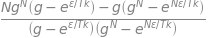

In [3]:
g, N, epsilon, k, T = sp.symbols('g, N, epsilon, k, T')

Z   = (1 - (g**N*sp.exp(-N*epsilon/(k*T))))/(1 - g*sp.exp(-epsilon/(k*T))) 
avn = (1/epsilon)*sp.simplify( ( k*T**2*sp.diff(Z,T)/Z) )
avn

which can be simplified by dividing common factors 

$$\displaystyle \langle n\rangle = \frac{Ng^N}{g^N-e^{N\epsilon/k_BT}} -\frac{g}{g-e^{\epsilon/k_BT}}=\frac{N}{1-(e^{\epsilon/k_BT}/g)^N} -\frac{1}{1-e^{\epsilon/k_BT}/g}\qquad\tag{12b}$$

whose behaviour is easier to see in a plot of $\langle n\rangle$ _vs._ $\epsilon/k_BT$.

![Drawing](series-fig2c.png)  

Figure 1f. Average length of free links in the zipper model $\langle n\rangle$ _vs._ dimensionless energy $\epsilon/k_BT$. The vertical line is at $\ln(g)=\epsilon/k_BT$.
______

At low values of $\epsilon/k_BT$, which means at high temperature or zero energy to unfold, almost the whole zipper is unfolded, as intuition would suggest Conversely at large $\epsilon/k_BT$, low temperature or large unfolding energy almost all bonds are intact. The transition between the two is quite sharp and occurs at $\ln(g)=\epsilon/k_BT$ as can be seen in equation 12b. The heat capacity which is $d\langle E\rangle/dT$ shows a sharp peak at this value. This overall behaviour  somewhat unexpected, the model does not immediately suggest that a 'phase transition' should occur. In effect it means that either the zipper is closed or it is fully open and hardly ever in between. 

## 5.3 Entropy of atoms and molecules

In the gas phase the entropy of atoms can be calculated knowing the contribution from translation and electronic terms. The calculation is in two parts, first the partition function must be evaluated and then used to obtain the entropy. 

The electronic part of the entropy is not zero if there are low lying electronic states as there are in carbon atoms. These are populated according the the Boltzmann distribution and increasingly so with temperature increase. The partition function and therefore the entropy due to translational motion similarly increases as the temperature increases. This occurs because more energy levels become populated and thus there are more ways to arrange the available energy.

To calculate the entropy we start with the partition function as in eqn. 11. The partition function for electronic energy levels is straightforward and is

$$\displaystyle Z = \sum_J (2J+1)e^{-E_J/k_BT}\qquad\tag{12c}$$

where $J$ is the total angular momentum of the electrons consisting of both spin and orbital parts and the degeneracy is $g = 2J+1$. The term symbol contains the information and has the forms $\displaystyle ^{(2S+1)}A_J$ where $S$ is the total spin, so $2S+1$ is the spin degeneracy as singlet ($S=0$), doublet ($S=1/2$), triplet ($S=1$) etc. The letter $A$ indicates the orbital angular momentum $L$ and if $L=0$ then $A=S$, if $L=1$  $A=P$ etc. and the subscript $J$ is the total which ranges as $J=|L+S|\cdots \to \cdots |L-S|$ in unit steps. Thus $^1D_2$ is a state that has total spin $S=0$, orbital angular momentum $L=2$ and total angular momentum $J=2$.

The spectroscopic data for carbon atoms can be found on the NIST WebBook website and the lowest few levels in cm$^{-1}$ are

$$\displaystyle \begin{array}\\
\hline
\text{config} & \text{term symbol} & \text{energy } /\mathrm{cm^{-1}}\\
\hline
 2s^2.2p^2&	^3P_0& 	  0.0000000 \\	
 2s^2.2p^2& ^3P_1& 	  16.4167130\\ 	
 2s^2.2p^2& ^3P_2& 	  43.4134567\\ 	
 2s^2.2p^2& ^1D_2& 	  10192.657 \\	
 2s^2.2p^2& ^1S_0& 	  21648.030 \\	
 2s^1.2p^3&	^5S_2& 	  33735.121 \\
 \hline \end{array}$$
 
In calculating the partition function for 'internal' energy, the levels at several thousand wavenumbers above the ground state contribute very little to the summation due to the exponential becoming very small. At $300$ K, $k_BT = 207\,\mathrm{cm^{-1}}$ therefore the energy level at $10192.6\,\mathrm{cm^{-1}}$, and also those at higher energy, contributes insignificantly, e.g $(2\times 2+1)e^{-10192.6/207} \approx 2\cdot 10^{-21} $ so is utterly negligible. Only the first three terms need be included making the partition function $Z_{int}= 18.24$. This is a small value compared to the translational value.

In a molecule, there are in addition to electronic states, vibrational and rotational energy levels and these, particularly the latter, can be very numerous. If there are $N$ atoms there are $3N-6$ vibrational normal modes if the molecule is non-linear and $3N-5$ if it is. Each vibrational level has a stack of rotational levels these being $2J+1$ degenerate with rigid rotor energy  $2B(J+1)$ where $J$ is the rotational quantum number. The rotational constant $B$ is often small, just a fraction to a few a wavenumbers being typical. The vibrational frequency and rotational constant for I$_2$ and CO molecules are respectively $(214.57, 0.03735)$ and  $(2214.24,1.9313)\,\mathrm{cm^{-1}}$.

The translational part of the partition function is found by examining the energy levels of a particle in a box. As there is no potential energy  these levels give the kinetic energy. The box has infinitely high walls with zero potential between them. We shall suppose that the atoms are in boxes whose size is very large compared to atomic dimensions so that the energy levels effectively become continuous. In a box these levels are

$$\displaystyle \epsilon_x= \frac{h^2}{8m}\left(\frac{n_x}{a^2}+\frac{n_y}{b^2}+\frac{n_z}{c^2}\right)$$

where $a,b,c$ is the lengths of the sides, $m$ the atom's mass and $n_x=n_y=n_z =1,2,\cdots $ are the quantum numbers.

The partition function from eqn. 11 is the triple summation over the quantum numbers in $x,y,z$

$$\displaystyle Z=\sum_{n_x}^\infty\sum_{n_y}^\infty\sum_{n_z}^\infty \large {e^{-(h^2/8mk_BT)(n_x^2/a^2+n_y^2/b^2+n_z^2/c^2) }}$$

which, because the summation in the exponential can be split into the product of three similar summations, form the product $Z=z_xz_yz_z$ where

$$\displaystyle z_x=\sum_{n_x}^\infty e^{-(h^2/8mk_BT)(n_x^2/a^2) }$$

and similarly for $z_y,z_z$. The energy levels in translational motion are too close together to be observable and thus the summation can be replaced with an integration (from zero) without introducing any significant error.  With the substitution $w=h^2/8ma^2k_BT $ the change is 

$$\displaystyle z_x=\sum_{n_x}^\infty e^{-wn_x^2 } \qquad \longrightarrow \qquad  \int_0^\infty e^{-wn^2} dn=\frac{1}{2}\sqrt{\frac{\pi}{w}}$$

The final partition function is the product of three similar terms and substituting back gives

$$\displaystyle Z= V\left(\frac{2\pi m k_BT}{h^2}\right)^{3/2}\qquad\tag{12d}$$

where the volume is $V=abc$. Substituting in values for the partition function produces a very large number. The mass must be in kg, $k_B$ in J/K and temperature in degrees Kelvin. The volume can be found using the ideal gas law with pressure for $1$ atm. expressed in Pascals; $V=RT/p$ where $p=101325$ Pa.  The result for carbon atoms is $Z = 10^{30}$. As we shall see the entropy has terms in $\ln(Z)$ so the difference in the electronic and translational partition functions is not so great as it first seems.

The entropy calculated by Statistical Mechanics is, for an ideal monoatomic gas of $N$ atoms,

$$\displaystyle S= Nk_B\ln \left(\frac{Z}{N} \right)+ \frac{U}{T} + Nk_B \qquad\tag{12e}$$

where $U$ is the internal energy where

$$\displaystyle U = Nk_BT^2 \left(\frac{\partial \ln(Z)}{\partial T} \right)_V\qquad\tag{12f}$$

Differentiating to obtain $U$ gives

$$\displaystyle U= Nk_BT^2\frac{3}{2T}= \frac{3}{2}Nk_BT$$

which is the same result as from the kinetic theory of gases for a monoatomic gas and at equilibrium produces energy of $k_BT/2$ per degree of freedom.

After substituting and some rearranging the entropy is

$$\displaystyle S=Nk_B\left(\frac{3}{2}\ln(T)+ \ln\left(\frac{V}{N} \right)+\frac{3}{2}\ln\left(\frac{2\pi mk_B}{h^2} \right) +\frac{5}{2}\right)\qquad\tag{12g}$$

and in terms of pressure substitute $V=Nk_BT/p$. 

If we take a mole of gas then $N\to N_A$ Avogadro's number and $Nk_B=R$ the gas constant, then

$$\displaystyle S=R\left(\frac{5}{2}\ln(T)+ \ln\left(\frac{k_B}{p} \right)+\frac{3}{2}\ln\left(\frac{2\pi mk_B}{h^2} \right) +\frac{5}{2}\right)\qquad\tag{12h}$$

The thermodynamic calculation gives the entropy as 

$$\displaystyle S_{thermo}= \frac{3}{2}R\ln(T) +R\ln(V) +S_0$$

which is the same as derived above but with the Statistical Mechanics calculation the constant $S_0$ is now determined. Additionally the dependence on mass is explained. This dependence is because the energy levels in the particle in a box depend inversely on the mass. As the mass increases more energy levels are available to be filled at a given temperature which produces more ways of distributing the energy among these levels which increases the entropy.

The translational entropy for carbon atoms is $S_{trans} = 139.8$ J/mol/K.

The calculation of the internal entropy, i.e. that due to energy levels within the atom or molecule is given by a related formula to 12e which is

$$\displaystyle S= Nk_B\ln(Z)+ \frac{U}{T} \qquad\tag{12i}$$

The internal energy (12f) is found most easily using $\displaystyle \frac{d \ln(Z)}{dT}=\frac{1}{Z}\frac{dZ}{dT}$  

$$\displaystyle U = Nk_BT \frac{\sum_{J=0}^\infty\limits E_J(2J+1)e^{-E_J/k_BT}}{\sum_{J=0}^\infty\limits (2J+1)e^{-E_J/k_BT}} $$

The ratio of summations has the form of an average, see eqn. 8. This is to be expected in hindsight as we assume thermal equilibrium and so the energy over many levels should be the average value. 

The entropy/mole becomes

$$\displaystyle S_{int}= R\ln\left(\sum_{J=0}^\infty (2J+1)e^{-E_J/k_BT}\right) + \frac{N_A}{T} \frac{\sum_{J=0}^\infty\limits E_J(2J+1)e^{-E_J/k_BT}}{\sum_{J=0}^\infty\limits (2J+1)e^{-E_J/k_BT}} $$

which more concisely is 

$$\displaystyle S_{int}= R\ln(Z) + \frac{N_A}{T} \langle E\rangle $$

The values for the electronic energies of C atoms are given above making the contribution to the entropy at $300$ K from these states $S_{int}= 18.24\; \mathrm{J/mol/K} $ and the total entropy is $S= 158.12$ J/mol/K which is acceptably close to the experimental, calorimetric value of $158.10$. The calculation is shown below.

The translational entropy of a molecule will increase only as $\ln(m)$ eqn. 12h which is a relatively small change with increasing mass, however, the internal entropy changes by far more largely because of the many, possibly hundreds, of closely spaced rotational energy levels needed to be included in the calculation. In the case of CO the calculated and experimental values agree well, both at $197.6$ J/mol/K, but the case of I$_2$ where the internal entropy is $88.7$ J/mol/K and the translational one $177.9$ make the total $266.5$. This is quite a bit larger than the experimental value of $260.7$ J/mol/K. Possibly this is due to the formulas describing the energy levels not being sufficiently accurate for higher vibrational and rotational levels, since the same trend also occurs with chlorine but to a smaller extent.

In [4]:
# Entropy of atoms   Now using numpy
h   = 6.62607e-34  # Planck constant, J s
N_A = 6.02214e23   # Avogadro number, 1/mol
kB  = 1.38065e-23  # Boltzmann constant, J/K
amu = 1.66054e-27  # atomic mass unit, kg
cmJ = 1.96e-23     # wavenumber to joules 
p   = 101325.0     # Pressure, pascal
R   = N_A*kB       # Ideal gas constant, J/mol/K

T = 300

# carbon data from NIST WebBook
m = 12.011
En= [0.0000000 ,16.4167130, 43.4134567]
J = [0,1,2]

V = R*T/p
Ztrans = V*(2*np.pi*m*amu*kB*T/h**2)**(3/2)
#print('{:s}{:10.4g}'.format('Z trans',Ztrans))

S_trans= R*(5/2*np.log(T) + np.log(kB/p) + 3/2*np.log(2*np.pi*m*amu*kB/h**2)  + 5/2 )
print('{:s} {:8.4f} {:s}'.format('S translation',S_trans, ' J/mol/K') )

ZE = 0.0
Z  = 0.0
for i in range(len(J)):
    temp = (2*J[i]+1)*np.exp(-En[i]*cmJ/(kB*T))
    Z  = Z + temp
    ZE = ZE+ En[i]*cmJ*temp  # average energy

S_int = R*np.log(Z) + N_A*ZE/(T*Z)

print('{:s} {:8.4f} {:s}'.format('S internal   ', S_int,  ' J/mol/K') )
print('{:s} {:8.4f} {:s}'.format('S total      ', S_int+S_trans,' J/mol/K') )

S translation 139.8770  J/mol/K
S internal     18.2438  J/mol/K
S total       158.1208  J/mol/K
